#AI Job Market Data Analysis


##Problem Statement
The objective of this project is to analysis the AI job market data for the **identifying the trends** in this sector, **required skills**, **salary distribution** and **how skill demand evolves over time**.

## Dataset Overview

The dataset contains information about AI related job postings. Including:
- Job title
- Required skills
- Experience level
- Employment type
- Salary range
- Job posting date

**CODE**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

Saving ai_job_market.csv to ai_job_market.csv


In [ ]:
df=pd.read_csv("ai_job_market.csv")
df.head()

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain"
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,"FastAPI, KDB+, TensorFlow"
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,"BigQuery, PyTorch, Scikit-learn"
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,"TensorFlow, BigQuery, MLflow"
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,Large,"PyTorch, LangChain"


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_id            2000 non-null   int64 
 1   company_name      2000 non-null   object
 2   industry          2000 non-null   object
 3   job_title         2000 non-null   object
 4   skills_required   2000 non-null   object
 5   experience_level  2000 non-null   object
 6   employment_type   2000 non-null   object
 7   location          2000 non-null   object
 8   salary_range_usd  2000 non-null   object
 9   posted_date       2000 non-null   object
 10  company_size      2000 non-null   object
 11  tools_preferred   2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


,job_id
count,2000.000000
mean,1000.500000
std,577.494589
min,1.000000
25%,500.750000
50%,1000.500000
75%,1500.250000
max,2000.000000


**Data Cleaning**

Data set was cleaned by handling missing values and transforming salary ranges into numerical values to enable analysis

In [ ]:
#Check missing values
df.isnull().sum()

,0
job_id,0
company_name,0
industry,0
job_title,0
skills_required,0
experience_level,0
employment_type,0
location,0
salary_range_usd,0
posted_date,0


**Exploratory Data Analysis(EDA)**

In [ ]:
#Most Appearing Job Role
df['job_title'].value_counts().head(20)


,count
job_title,
Data Analyst,271
NLP Engineer,265
AI Product Manager,258
Quant Researcher,251
ML Engineer,250
Data Scientist,238
AI Researcher,237
Computer Vision Engineer,230


In [ ]:
df['salary_range_usd'].head()
df['salary_range_usd'].dtype

dtype('O')

In [ ]:
#split salary range into Min & Max

In [ ]:
df[['salary_min', 'salary_max']] = df['salary_range_usd'].str.split('-', expand=True)


In [ ]:
#convert to Numeric
df['salary_min'] = df['salary_min'].astype(int)
df['salary_max'] = df['salary_max'].astype(int)


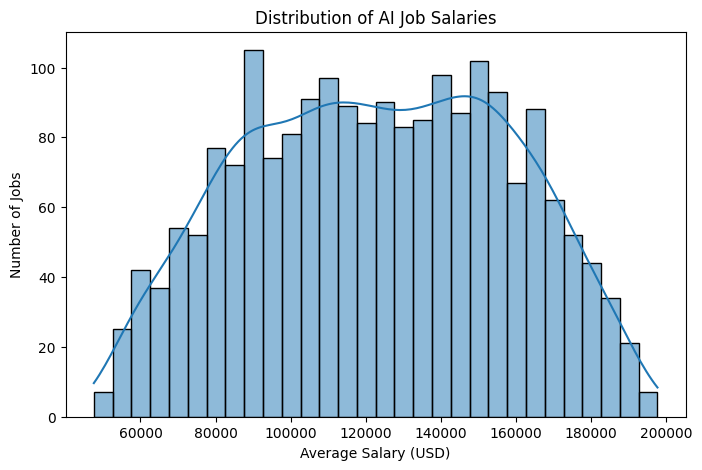

In [ ]:
#create Average Salary
df['salary_avg'] = (df['salary_min'] + df['salary_max']) / 2
#plot histogram
plt.figure(figsize=(8,5))
sns.histplot(df['salary_avg'], bins=30, kde=True)
plt.xlabel("Average Salary (USD)")
plt.ylabel("Number of Jobs")
plt.title("Distribution of AI Job Salaries")
plt.show()


**Salary vs Experience Level**

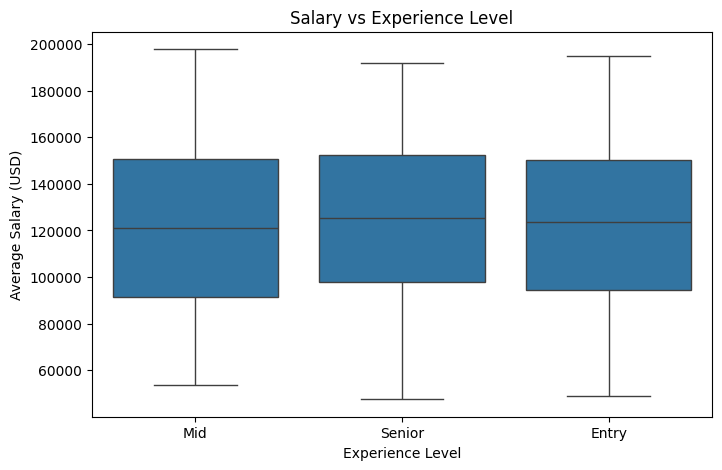

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='experience_level', y='salary_avg', data=df)
plt.title("Salary vs Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")
plt.show()

In [ ]:
df[['job_title','skills_required']].head()
#convert to lowercase and split skills
df['skills_list'] = df['skills_required'].str.lower().str.split(',')

#remove extra spaces
df['skills_list'] = df['skills_list'].apply(
    lambda skills: [skill.strip() for skill in skills]
)
#convert 1 row into multiple rows
df_exploded=df.explode('skills_list')
df_exploded.head()


,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred,salary_min,salary_max,salary_avg,skills_list
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain",92860,109598,101229.0,numpy
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain",92860,109598,101229.0,reinforcement learning
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain",92860,109598,101229.0,pytorch
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain",92860,109598,101229.0,scikit-learn
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain",92860,109598,101229.0,gcp


In [ ]:
#Top 5 skills per role
top_skills = (
    df_exploded
    .groupby(['job_title', 'skills_list'])
    .size()
    .reset_index(name='count')
)

#proper sorting
top_skills = top_skills.sort_values(['job_title', 'count'], ascending=[True, False])

top_5_skills = top_skills.groupby('job_title').head(5)
top_5_skills


,job_title,skills_list,count
12,AI Product Manager,numpy,66
11,AI Product Manager,mlflow,63
20,AI Product Manager,sql,60
2,AI Product Manager,c++,58
17,AI Product Manager,r,57
35,AI Researcher,pandas,60
36,AI Researcher,power bi,58
34,AI Researcher,numpy,57
22,AI Researcher,aws,54
26,AI Researcher,excel,53


**Visualization**

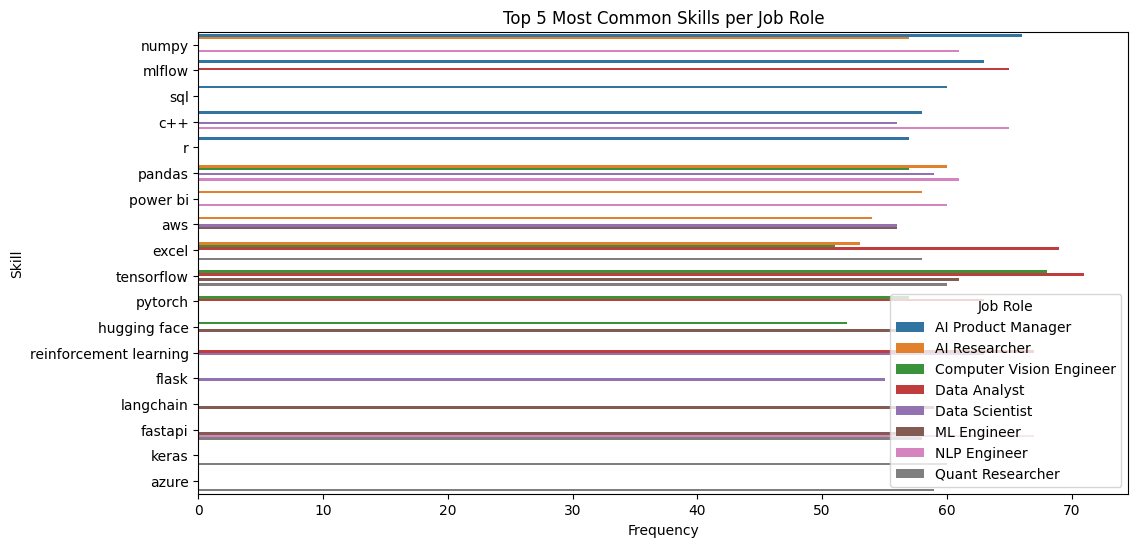

In [ ]:
#Bar chart for skills per job role
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_5_skills,
    x='count',
    y='skills_list',
    hue='job_title'
)
plt.title("Top 5 Most Common Skills per Job Role")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.legend(title="Job Role")
plt.show()


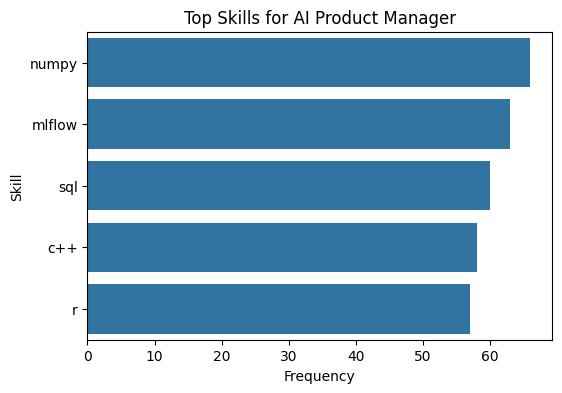

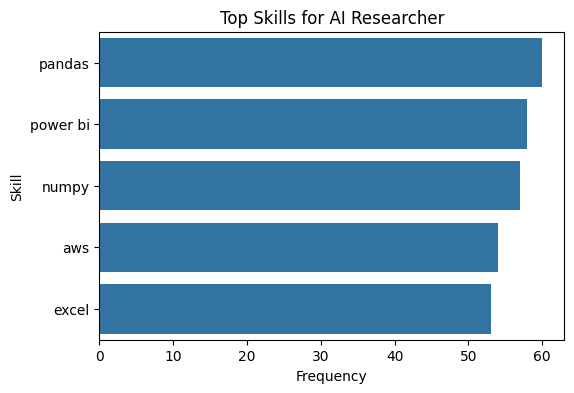

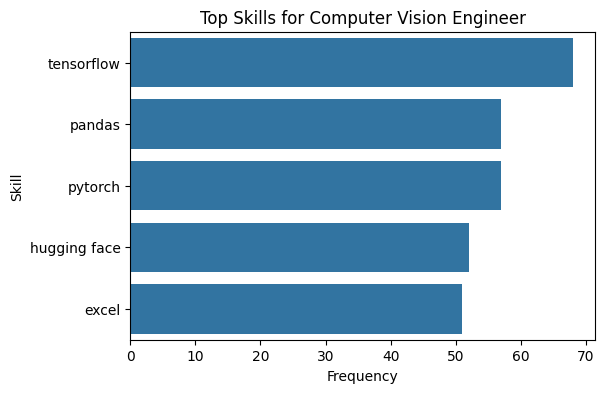

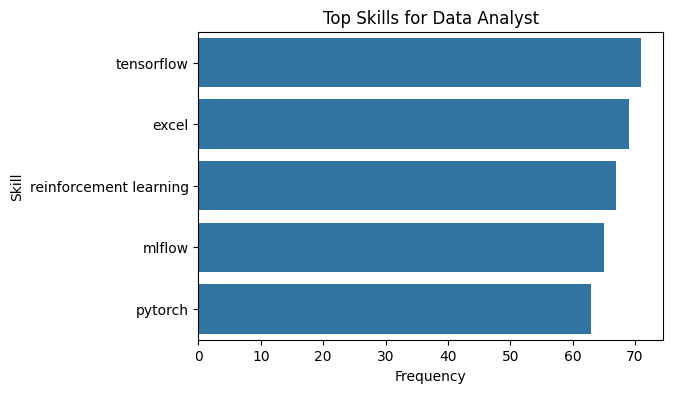

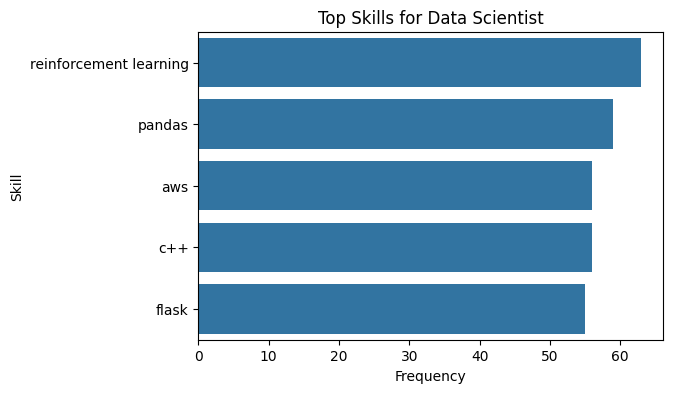

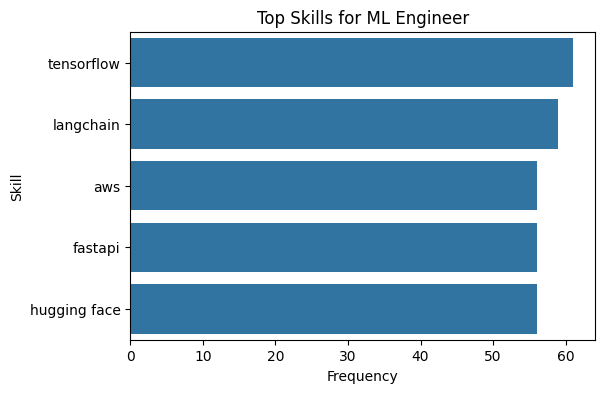

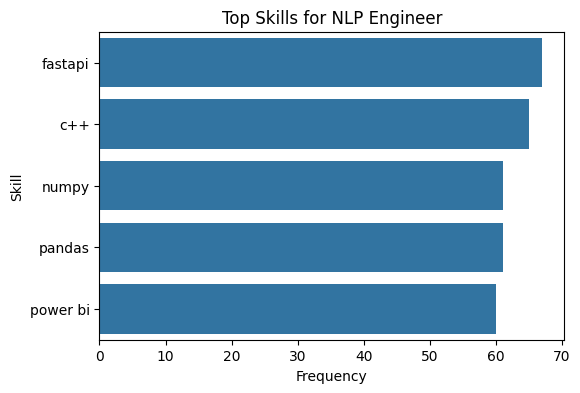

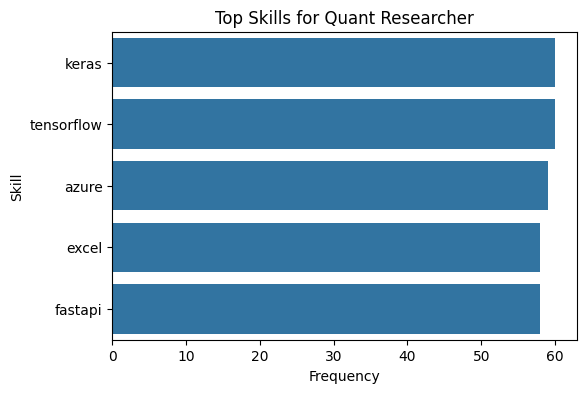

In [ ]:
for role in top_5_skills['job_title'].unique():
    data = top_5_skills[top_5_skills['job_title'] == role]

    plt.figure(figsize=(6,4))
    sns.barplot(x='count', y='skills_list', data=data)
    plt.title(f"Top Skills for {role}")
    plt.xlabel("Frequency")
    plt.ylabel("Skill")
    plt.show()
